In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import os
from sklearn.model_selection import train_test_split 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
        Dense, 
        LSTM,
        Dropout)

In [81]:
dataset_name="apple"
df=pd.read_csv(f"../data/after_F_eng/{dataset_name}_F_Eng.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Asset_Name,MA_7,MA_30,Daily_Return,...,Year,DayOfWeek,Quarter,Close_lag1,Close_lag2,Close_lag7,EMA_7,Price_Range,Open_Close_Diff,Rolling_STD_7
0,1984-10-18,0.096209,0.096821,0.096209,0.096209,292680633,Apple,0.090605,0.096592,0.028945,...,1984,3,4,0.093503,0.089868,0.092594,0.092333,0.000612,0.000000,0.003428
1,1984-10-19,0.096209,0.102846,0.095903,0.096209,386182514,Apple,0.091510,0.096471,0.000000,...,1984,4,4,0.096209,0.093503,0.089868,0.093302,0.006943,0.000000,0.003993
2,1984-10-22,0.096209,0.097710,0.095587,0.095587,135889371,Apple,0.092412,0.096350,-0.006468,...,1984,0,4,0.096209,0.096209,0.089275,0.093873,0.002123,0.000622,0.004115
3,1984-10-23,0.097710,0.098619,0.097710,0.097710,220770467,Apple,0.094179,0.096239,0.022215,...,1984,1,4,0.095587,0.096209,0.085345,0.094832,0.000909,0.000000,0.003105
4,1984-10-24,0.098619,0.099824,0.098619,0.098619,197772989,Apple,0.095386,0.096259,0.009299,...,1984,2,4,0.097710,0.095587,0.090164,0.095779,0.001205,0.000000,0.002922


In [82]:
df["Target"] = df["Close"].shift(-7)

df=df.dropna()

y=df["Target"]

X = df.drop(
    columns=[
        "Close",
        "Target",
        "Date",
        "Asset_Name"
    ]
)


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)
y_test_original = y_test.copy()

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

joblib.dump(
    scaler,
    f"../models/{dataset_name}/{dataset_name}_scaler.pkl"
)

X_test_scaled = scaler.transform(
    X_test
)

LINEAR REGRESSION

In [85]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

In [86]:
print("Linear Regression Results")
print()

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results

MAE: 3.9627063440189687
RMSE: 5.614538805729664
R2: 0.9921119969074494


In [87]:
joblib.dump(
    lr_model,
    f"../models/{dataset_name}/{dataset_name}_lr_model.pkl"
)

['../models/apple/apple_lr_model.pkl']

RANDOM FOREST

In [88]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf_model.predict(
    X_test_scaled
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

In [89]:
print("Random Forest Results")
print()

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results

MAE: 84.3257924637395
RMSE: 105.48081401344275
R2: -1.7841064840926384


In [90]:
joblib.dump(
    rf_model,
    f"../models/{dataset_name}/{dataset_name}_rf_model.pkl"
)

['../models/apple/apple_rf_model.pkl']

XGBOOST

In [91]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model.fit(
    X_train_scaled,
    y_train
)
xgb_pred = xgb_model.predict(
    X_test_scaled
)
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)
xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

In [92]:
print("XGBoost Results")
print()

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Results

MAE: 84.91272332707364
RMSE: 105.91927788664911
R2: -1.8073006032589052


In [93]:
joblib.dump(
    xgb_model,
    f"../models/{dataset_name}/{dataset_name}_xgb_model.pkl"
)

['../models/apple/apple_xgb_model.pkl']

LSTM

In [94]:
df = pd.read_csv(
    f"../data/after_f_Eng/{dataset_name}_F_Eng.csv"
)

In [95]:
data = df[["Close"]]

lstm_scaler = MinMaxScaler()
scaled_data = lstm_scaler.fit_transform(
    data
)

joblib.dump(
    lstm_scaler,
    f"../models/{dataset_name}/{dataset_name}_lstm_scaler.pkl"
)
X = []
y = []
sequence_length = 30
for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    y.append(
        scaled_data[i]
    )
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10112, 30, 1)
y shape: (10112, 1)


In [96]:
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8089, 30, 1)
y_train shape: (8089, 1)
X_test shape: (2023, 30, 1)
y_test shape: (2023, 1)


In [97]:
lstm_model = Sequential()
lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)
lstm_model.add(
    Dropout(0.2)
)
lstm_model.add(
    LSTM(
        units=50
    )
)
lstm_model.add(
    Dropout(0.2)
)
lstm_model.add(
    Dense(1)
)
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)
lstm_model.summary()

c:\Users\Maria\Documents\Projects\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.4004e-05 - val_loss: 0.0011
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3731e-05 - val_loss: 8.5178e-04
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.1462e-05 - val_loss: 4.7512e-04
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.9093e-06 - val_loss: 0.0064
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.0008e-05 - val_loss: 0.0037
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.5540e-06 - val_loss: 0.0022
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.9566e-06 - val_loss: 0.0023
Epoch 8/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.7058e-06 - val_loss: 0.0011
Epoch 9/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.7497e-06 - val_loss: 0.0025
Epoch 10/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.1551e-06 - val_loss: 0.0016
Epoch 11/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.5791e-06 - val_lo

In [99]:
predictions = lstm_model.predict(
    X_test
)
predictions = lstm_scaler.inverse_transform(
    predictions
)

y_test_actual = lstm_scaler.inverse_transform(
    y_test
)

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [100]:
lstm_mae = mean_absolute_error(
    y_test_actual,
    predictions
)
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

lstm_r2 = r2_score(
    y_test_actual,
    predictions
)

print("LSTM Results for", dataset_name)
print()

print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2:", lstm_r2)

LSTM Results for apple

MAE: 10.050969778540436
RMSE: 13.90517012751674
R2: 0.9515389025557193


In [101]:

lstm_model.save(f"../models/{dataset_name}/{dataset_name}_lstm_model.h5")

Comparison Table

In [102]:
comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae,
        lstm_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        lstm_rmse
    ],

    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2,
        lstm_r2
    ]
})

In [103]:
comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
)

In [104]:
comparison_df.to_csv(
    f"../results/{dataset_name}/{dataset_name}_comparison.csv",
    index=False
)

In [105]:
best_model = comparison_df.iloc[0]["Model"]

worst_model = comparison_df.iloc[-1]["Model"]

print("Best Model:", best_model)

print("Worst Model:", worst_model)

Best Model: Linear Regression
Worst Model: XGBoost


In [106]:
prediction_dict = {

    "Linear Regression": {
        "actual": y_test_original,
        "predicted": lr_pred
    },

    "Random Forest": {
        "actual": y_test_original,
        "predicted": rf_pred
    },

    "XGBoost": {
        "actual": y_test_original,
        "predicted": xgb_pred
    },

    "LSTM": {
        "actual": y_test_actual.flatten(),
        "predicted": predictions.flatten()
    }

}

In [107]:
best_actual = prediction_dict[
    best_model
]["actual"]

best_predictions = prediction_dict[
    best_model
]["predicted"]

In [108]:
best_actual = np.array(
    best_actual
).flatten()

best_predictions = np.array(
    best_predictions
).flatten()

min_length = min(
    len(best_actual),
    len(best_predictions)
)

In [109]:
pred_df = pd.DataFrame({

    "Actual": best_actual[:min_length],

    "Predicted": best_predictions[:min_length]

})

In [110]:
pred_df.to_csv(
    f"../results/{dataset_name}/{dataset_name}_predictions.csv",
    index=False
)

In [111]:
print(y_test[:5])

[[0.10375354]
 [0.10363923]
 [0.10417676]
 [0.10532092]
 [0.1062863 ]]


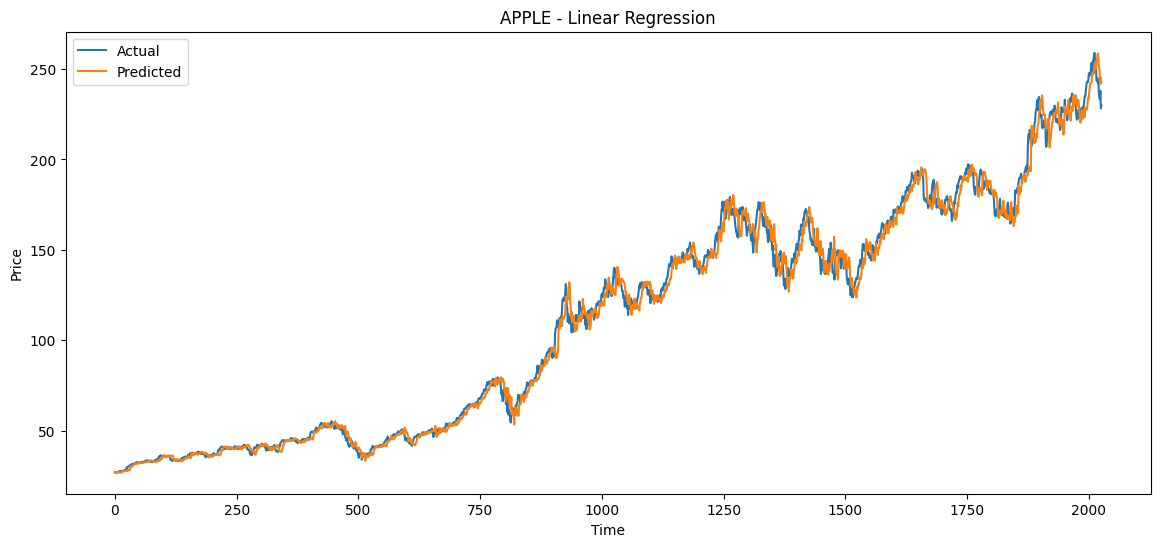

In [112]:
plt.figure(figsize=(14,6))

plt.plot(
    pred_df["Actual"],
    label="Actual"
)

plt.plot(
    pred_df["Predicted"],
    label="Predicted"
)

plt.title(
    f"{dataset_name.upper()} - {best_model}"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()